# Telco Customer Churn Analysis

## Business Objective

Our target is:

> **Why are customers churning?**

We will investigate whether different categorical customer characteristics
are associated with customer churn.

### Statistical tools

1. Chi-Square Test of Independence
2. Expected Frequencies
3. Pearson Residuals
4. Residual Heatmap
5. Cramér's V

### Main questions

- Which categorical variables are associated with churn?
- Is the association statistically significant?
- Which categories contribute most to churn?
- How strong is the association?

In [3]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

# Load data
df = pd.read_excel("Telco_customer_churn.xlsx")

# List of categorical features (excluding Tenure Months as it is numerical)
Qualitative_Columns = [
    "Gender",
    "Senior Citizen",
    "Partner",
    "Dependents",
    "Phone Service",
    "Multiple Lines",
    "Internet Service",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Contract",
    "Paperless Billing",
    "Payment Method",
]

Target_Columns = "Churn Label"


# Helper function to categorize Cramér's V strength
def get_strength_label(v):
    if v < 0.10:
        return "Very Weak"
    elif v < 0.20:
        return "Weak"
    elif v < 0.40:
        return "Moderate"
    elif v < 0.60:
        return "Strong"
    elif v < 0.80:
        return "Very Strong"
    else:
        return "Extremely Strong"


def find_churn_associations(data, cat_cols, target, alpha=0.05):
    """Performs Chi-Square Test, calculates Cramér's V, and adds Strength Label."""
    results = []

    for col in cat_cols:
        # Contingency Table & Chi-Square Test
        contingency_table = pd.crosstab(data[col], data[target])
        chi2, p, dof, expected = chi2_contingency(contingency_table)

        # Cramér's V
        n = contingency_table.sum().sum()
        r, k = contingency_table.shape
        cramers_v = np.sqrt(chi2 / (n * (min(r, k) - 1)))

        is_significant = p < alpha
        strength = get_strength_label(cramers_v)

        results.append((col, chi2, p, cramers_v, is_significant, strength))

    # Sort by Cramér's V descending
    results.sort(key=lambda x: x[3], reverse=True)
    return results

In [4]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt
# Reading Xlsx File is important
df = pd.read_excel("Telco_customer_churn.xlsx")
# Quantitative Columns
Qualitative_Columns = ["Gender","Senior Citizen","Partner","Dependents","Tenure Months","Phone Service","Multiple Lines","Internet Service","Online Security","Online Backup","Device Protection","Tech Support","Streaming TV","Streaming Movies","Contract","Paperless Billing","Payment Method"]
# which  columns is our target to Compare
Target_Columns = "Churn Label"
# a fuction need to define that returns  a tuple of  columns  that uses  Qualitative columns  to find association with churn
# Execute function
churn_associations = find_churn_associations(
    df, Qualitative_Columns, Target_Columns
)

# Convert to DataFrame
results_df = pd.DataFrame(
    churn_associations,
    columns=[
        "Column",
        "Chi2 Statistic",
        "p-value",
        "Cramers V",
        "Is Significant",
        "Association Strength",
    ],
)

print(results_df)

               Column  Chi2 Statistic        p-value  Cramers V  \
0            Contract     1184.596572  5.863038e-258   0.410116   
1       Tenure Months     1065.330857  1.280781e-176   0.388923   
2     Online Security      849.998968  2.661150e-185   0.347400   
3        Tech Support      828.197068  1.443084e-180   0.342916   
4    Internet Service      732.309590  9.571788e-160   0.322455   
5      Payment Method      648.142327  3.682355e-140   0.303359   
6       Online Backup      601.812790  2.079759e-131   0.292316   
7   Device Protection      558.419369  5.505219e-122   0.281580   
8          Dependents      433.734379   2.500972e-96   0.248161   
9    Streaming Movies      375.661479   2.667757e-82   0.230951   
10       Streaming TV      374.203943   5.528994e-82   0.230502   
11  Paperless Billing      258.277649   4.073355e-58   0.191498   
12     Senior Citizen      159.426300   1.510067e-36   0.150453   
13            Partner      158.733382   2.139911e-36   0.15012

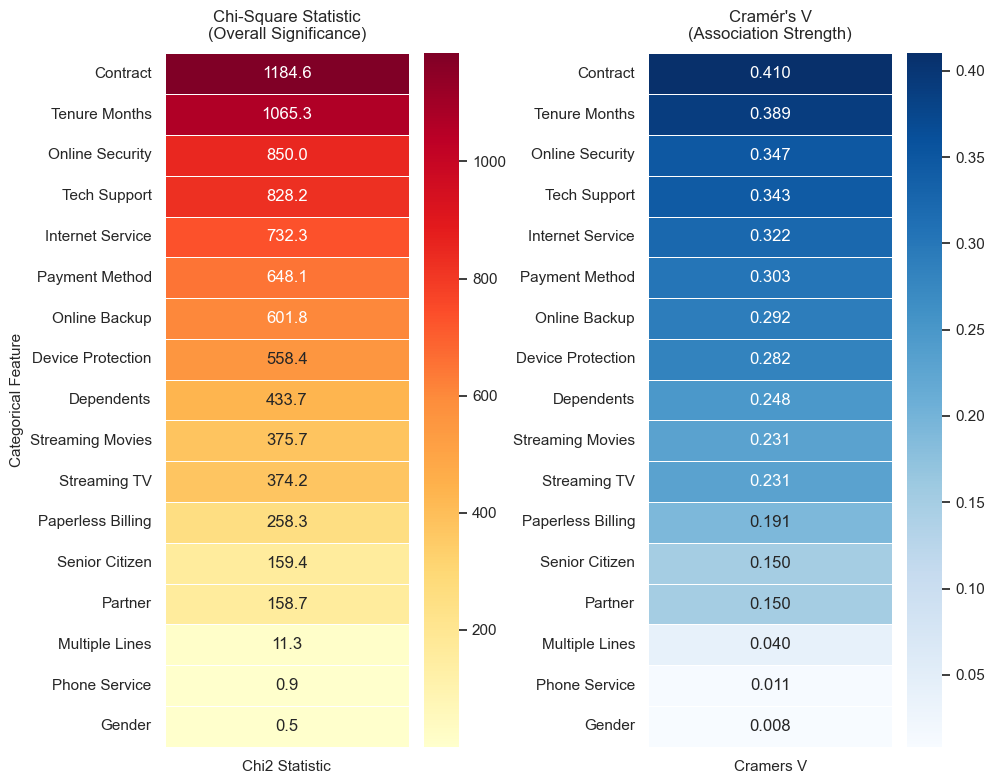

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set up data matrix for Heatmap (using Column as index)
chi2_matrix = results_df.set_index("Column")[["Chi2 Statistic"]]
cramers_matrix = results_df.set_index("Column")[["Cramers V"]]

# Set figure layout
fig, axes = plt.subplots(1, 2, figsize=(10, 8))

# 1. Chi-Square Statistic Heatmap
sns.heatmap(
    chi2_matrix,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    cbar=True,
    linewidths=0.5,
    ax=axes[0],
)
axes[0].set_title(
    "Chi-Square Statistic\n(Overall Significance)", fontsize=12, pad=10
)
axes[0].set_ylabel("Categorical Feature", fontsize=11)

# 2. Cramér's V Heatmap (Effect Size / Association Strength)
sns.heatmap(
    cramers_matrix,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    cbar=True,
    linewidths=0.5,
    ax=axes[1],
)
axes[1].set_title(
    "Cramér's V\n(Association Strength)", fontsize=12, pad=10
)
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

In [7]:
# Selected categorical features for training
selected_features = [
    "Contract",
    "Online Security",
    "Tech Support",
    "Internet Service",
    "Payment Method",
    "Online Backup",
    "Device Protection",
    "Dependents",
    "Streaming Movies",
    "Streaming TV",
    "Paperless Billing",
    "Senior Citizen",
    "Partner",
]

# Excluded columns
# ["Gender", "Phone Service", "Multiple Lines"]

In [8]:
import joblib

# Save selected feature list for later model training
joblib.dump(selected_features, "selected_features_chi2.pkl")

# Load it back whenever needed
# selected_features = joblib.load('selected_features_chi2.pkl')

['selected_features_chi2.pkl']